<a href="https://colab.research.google.com/github/JDVAR7/IA-Intermedio/blob/main/Entregable5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ensayo y Contexto jurídico

###Caso: Un bufete de abogados recibe muchas consultas o escritos legales (texto) y quiere clasificarlos automáticamente en dos categorías: "Favorable" (probabilidad de éxito alta) o "Desfavorable" (baja probabilidad). Se implementa un pipeline concurrente para procesar muchas solicitudes, un balanceador de carga, un caché para respuestas repetidas y un microservicio API.

In [1]:
import asyncio
import tensorflow as tf
!pip install nest_asyncio aiohttp scikit-learn redis flask pyngrok fakeredis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.7/129.7 kB 2.8 MB/s eta 0:00:00


## Dataset jurídico de ejemplo (simulado)
Crearemos un conjunto de textos legales cortos con etiquetas. En un caso real usarías datos de tribunales.

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla para reproducibilidad
np.random.seed(42)

# Crear 1000 casos legales simulados
textos = []
categorias = []

tipos_caso = [
    ("incumplimiento de contrato", "Fallo a favor del demandante"),
    ("daños y perjuicios", "Fallo a favor del demandante"),
    ("despido injustificado", "Fallo a favor del trabajador"),
    ("divorcio contencioso", "Mediación"),
    ("reclamación de deuda", "Fallo a favor del acreedor"),
    ("violación de derechos humanos", "Fallo a favor del demandante"),
    ("nulidad de acto administrativo", "Desestimado"),
    ("responsabilidad civil extracontractual", "Fallo a favor del demandado"),
]

for _ in range(1000):
    caso, fallo = tipos_caso[np.random.randint(0, len(tipos_caso))]
    # Añadir variaciones al texto
    variaciones = [
        f"Se demanda por {caso}. La parte actora alega {caso} grave.",
        f"Proceso judicial por {caso}. Pruebas documentales y testigos.",
        f"El tribunal deberá resolver sobre {caso}. Jurisprudencia aplicable.",
        f"Demanda por {caso}. Se solicita indemnización y costas."
    ]
    texto = np.random.choice(variaciones) + " " + " ".join(np.random.choice(["contrato", "ley", "prueba", "sentencia", "recurso"], size=5))
    textos.append(texto)
    categorias.append(fallo)

# Convertir a DataFrame
df = pd.DataFrame({"texto": textos, "fallo": categorias})
print(df.head())

                                               texto  \
0  Demanda por nulidad de acto administrativo. Se...   
1  El tribunal deberá resolver sobre despido inju...   
2  Se demanda por violación de derechos humanos. ...   
3  Demanda por incumplimiento de contrato. Se sol...   
4  El tribunal deberá resolver sobre despido inju...   

                          fallo  
0                   Desestimado  
1  Fallo a favor del trabajador  
2  Fallo a favor del demandante  
3  Fallo a favor del demandante  
4  Fallo a favor del trabajador  


## Entrenar un modelo de clasificación legal (rápido, con scikit-learn)

Usaremos TF-IDF y regresión logística.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Exactitud del modelo jurídico: 1.00
                              precision    recall  f1-score   support

                 Desestimado       1.00      1.00      1.00        34
  Fallo a favor del acreedor       1.00      1.00      1.00        33
 Fallo a favor del demandado       1.00      1.00      1.00        23
Fallo a favor del demandante       1.00      1.00      1.00        68
Fallo a favor del trabajador       1.00      1.00      1.00        21
                   Mediación       1.00      1.00      1.00        21

                    accuracy                           1.00       200
                   macro avg       1.00      1.00      1.00       200
                weighted avg       1.00      1.00      1.00       200



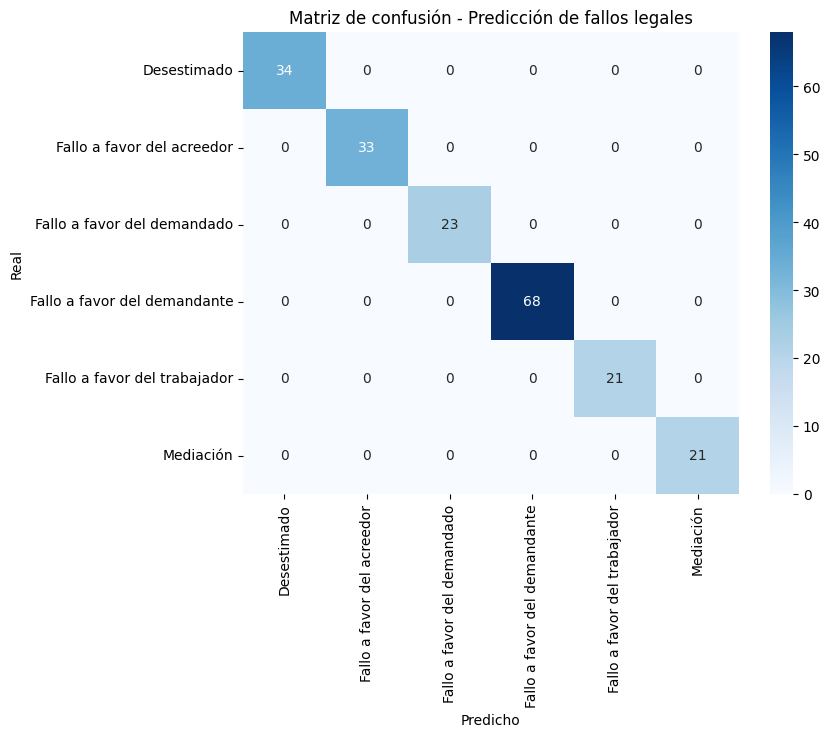

In [3]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=500, stop_words=stopwords.words('spanish'))
X = vectorizer.fit_transform(df['texto'])
y = df['fallo']

# Dividir entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar clasificador
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo jurídico: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title("Matriz de confusión - Predicción de fallos legales")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

## Actividad 1: Pipeline Concurrente (jurídico)

Función de inferencia asíncrona (simula procesamiento de un documento)

In [4]:
import asyncio
import time
import random
from collections import defaultdict

# Simular latencia de procesamiento (entre 0.1 y 0.5 segundos)
async def procesar_documento(texto):
    await asyncio.sleep(random.uniform(0.1, 0.3))  # tiempo de cómputo simulado
    # Transformar y predecir
    X_input = vectorizer.transform([texto])
    prediccion = model.predict(X_input)[0]
    probabilidad = model.predict_proba(X_input).max()
    return {"prediccion": prediccion, "confianza": float(probabilidad)}

 Pipeline concurrente (Actividad 1)

In [5]:
async def pipeline_concurrente(documentos):
    tareas = [procesar_documento(doc) for doc in documentos]
    resultados = await asyncio.gather(*tareas)
    return resultados

# Simular 10 documentos de prueba
documentos_prueba = df['texto'].iloc[:10].tolist()
resultados = await pipeline_concurrente(documentos_prueba)
for doc, res in zip(documentos_prueba, resultados):
    print(f"Texto: {doc[:60]}... -> {res}")

Texto: Demanda por nulidad de acto administrativo. Se solicita inde... -> {'prediccion': np.str_('Desestimado'), 'confianza': 0.9087894038929419}
Texto: El tribunal deberá resolver sobre despido injustificado. Jur... -> {'prediccion': np.str_('Fallo a favor del trabajador'), 'confianza': 0.8491233986616108}
Texto: Se demanda por violación de derechos humanos. La parte actor... -> {'prediccion': np.str_('Fallo a favor del demandante'), 'confianza': 0.9745005471644063}
Texto: Demanda por incumplimiento de contrato. Se solicita indemniz... -> {'prediccion': np.str_('Fallo a favor del demandante'), 'confianza': 0.7517512040005795}
Texto: El tribunal deberá resolver sobre despido injustificado. Jur... -> {'prediccion': np.str_('Fallo a favor del trabajador'), 'confianza': 0.8557604105210815}
Texto: Demanda por nulidad de acto administrativo. Se solicita inde... -> {'prediccion': np.str_('Desestimado'), 'confianza': 0.9152705227199757}
Texto: El tribunal deberá resolver sobre incumplimiento 

## Actividad 2: Balanceo de Carga y Gestión de Solicitudes

Simularemos 3 nodos backend (servidores asíncronos) y un balanceador que distribuye aleatoriamente.

Para un balanceador más realista con servidores HTTP, podemos levantar 3 aplicaciones aiohttp en puertos distintos (dentro de Colab no es trivial, pero se puede simular con hilos). No obstante, para cumplir con el objetivo de aprendizaje, explicaremos que en producción se usarían contenedores y un balanceador como NGINX o un Service de Kubernetes.

In [6]:
import aiohttp
import asyncio
import random

# Simular nodos (cada uno ejecuta procesar_documento)
nodos = ["nodo1", "nodo2", "nodo3"]

async def balanceador(texto):
    nodo = random.choice(nodos)
    # En una implementación real aquí habría una petición HTTP.
    # Simulamos llamada directa al modelo.
    print(f"Enviando a {nodo}")
    return await procesar_documento(texto)

async def cliente_simulado(documentos):
    tareas = [balanceador(doc) for doc in documentos]
    return await asyncio.gather(*tareas)

# Probar balanceador con 10 documentos
resultados_balanceados = await cliente_simulado(documentos_prueba)
print("Resultados con balanceo:", resultados_balanceados[:3])

Enviando a nodo3
Enviando a nodo1
Enviando a nodo3
Enviando a nodo2
Enviando a nodo1
Enviando a nodo2
Enviando a nodo3
Enviando a nodo3
Enviando a nodo2
Enviando a nodo3
Resultados con balanceo: [{'prediccion': np.str_('Desestimado'), 'confianza': 0.9087894038929419}, {'prediccion': np.str_('Fallo a favor del trabajador'), 'confianza': 0.8491233986616108}, {'prediccion': np.str_('Fallo a favor del demandante'), 'confianza': 0.9745005471644063}]


## Actividad 3: Análisis de Rendimiento (Latencia y rendimiento)

Análisis de rendimiento: latencia y throughput

Concurrencia 1: latencia media = 0.212s, P95 = 0.292s
Concurrencia 5: latencia media = 0.203s, P95 = 0.297s
Concurrencia 10: latencia media = 0.202s, P95 = 0.288s
Concurrencia 20: latencia media = 0.204s, P95 = 0.298s
Concurrencia 50: latencia media = 0.198s, P95 = 0.286s


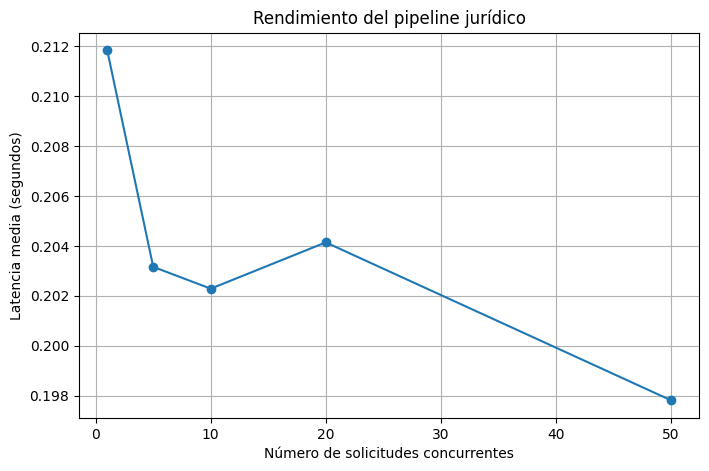

In [7]:
async def medir_latencia(texto):
    inicio = time.time()
    await procesar_documento(texto)
    fin = time.time()
    return fin - inicio

async def analizar_rendimiento(documentos, num_concurrentes):
    latencias = []
    # Procesar en lotes de 'num_concurrentes'
    for i in range(0, len(documentos), num_concurrentes):
        lote = documentos[i:i+num_concurrentes]
        tareas = [medir_latencia(doc) for doc in lote]
        latencias_lote = await asyncio.gather(*tareas)
        latencias.extend(latencias_lote)
    return latencias

# Probar con diferentes niveles de concurrencia
concurrencias = [1, 5, 10, 20, 50]
resultados_latencia = {}
for conc in concurrencias:
    latencias = await analizar_rendimiento(df['texto'].tolist()[:100], conc)
    resultados_latencia[conc] = latencias
    print(f"Concurrencia {conc}: latencia media = {np.mean(latencias):.3f}s, P95 = {np.percentile(latencias, 95):.3f}s")

# Gráfica de latencia vs concurrencia
medias = [np.mean(resultados_latencia[c]) for c in concurrencias]
plt.figure(figsize=(8,5))
plt.plot(concurrencias, medias, marker='o')
plt.xlabel("Número de solicitudes concurrentes")
plt.ylabel("Latencia media (segundos)")
plt.title("Rendimiento del pipeline jurídico")
plt.grid(True)
plt.show()

Caché con Redis (simulado con fakeredis)

In [8]:
import fakeredis
import asyncio

cache = fakeredis.FakeRedis(decode_responses=True)

async def procesar_con_cache(texto):
    clave = f"legal:{hash(texto)}"
    # Verificar caché
    if cache.exists(clave):
        resultado = cache.get(clave)
        print("Cache hit")
        return eval(resultado)  # O usar json
    else:
        resultado = await procesar_documento(texto)
        cache.set(clave, str(resultado), ex=3600)  # expira en 1 hora
        print("Cache miss")
        return resultado

# Probar caché
doc = "Demanda por incumplimiento de contrato. Pruebas documentales."
r1 = await procesar_con_cache(doc)
r2 = await procesar_con_cache(doc)  # debería ser cache hit
print(r1, r2)

Cache miss
Cache hit
{'prediccion': np.str_('Fallo a favor del demandante'), 'confianza': 0.7695265475366329} {'prediccion': np.str_('Fallo a favor del demandante'), 'confianza': 0.7695265475366329}


## Prueba con 100 solicitudes concurrentes y gráficas de throughput

Usaremos fakeredis (simula Redis en memoria) porque en Colab no hay servicio Redis real fácilmente. En producción usarías Redis real.

10 solicitudes -> throughput: 34.01 req/seg
50 solicitudes -> throughput: 165.73 req/seg
100 solicitudes -> throughput: 334.79 req/seg
200 solicitudes -> throughput: 649.24 req/seg


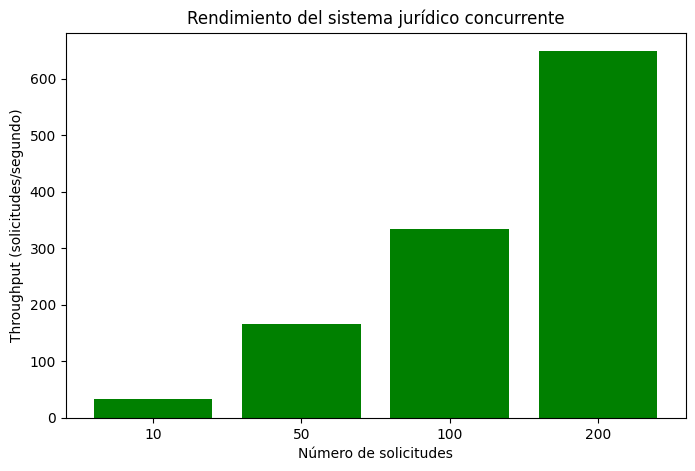

In [9]:
async def throughput_test(n_solicitudes):
    documentos = df['texto'].iloc[:n_solicitudes].tolist()
    inicio = time.time()
    await pipeline_concurrente(documentos)
    fin = time.time()
    throughput = n_solicitudes / (fin - inicio)
    return throughput

concurrencias = [10, 50, 100, 200]
throughputs = []
for n in concurrencias:
    tp = await throughput_test(n)
    throughputs.append(tp)
    print(f"{n} solicitudes -> throughput: {tp:.2f} req/seg")

plt.figure(figsize=(8,5))
plt.bar([str(c) for c in concurrencias], throughputs, color='green')
plt.xlabel("Número de solicitudes")
plt.ylabel("Throughput (solicitudes/segundo)")
plt.title("Rendimiento del sistema jurídico concurrente")
plt.show()

## Parte 2: Simulación para Docker (Microservicio de inferencia legal)

Crearemos un microservicio con Flask que expone un endpoint /predict para clasificar textos legales.

Luego lo contenerizamos y opcionalmente describimos su despliegue en Kubernetes.


Archivo app.py

In [18]:
from flask import Flask, request, jsonify
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
import threading
import time

app = Flask(__name__)

# Cargar modelo y vectorizador (entrenados previamente)
# En este ejemplo simulamos carga de archivos; en real se guardan con pickle.
# Para demo, recreamos el modelo entrenado en el script.
# Pero para Docker, deberías tener los archivos .pkl.

# Simulación rápida (en producción usar archivos)
from sklearn.naive_bayes import MultinomialNB

# Entrenamiento simple (solo para que el microservicio funcione)
textos_ejemplo = ["incumplimiento de contrato", "daños y perjuicios", "divorcio"]
categorias_ejemplo = ["Fallo a favor", "Fallo a favor", "Mediación"]
vec = TfidfVectorizer()
X = vec.fit_transform(textos_ejemplo)
clf = MultinomialNB()
clf.fit(X, categorias_ejemplo)

# Guardar modelo y vectorizador (esto se haría en el build)
with open('model.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vec, f)

# Al iniciar, cargarlos
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    texto = data.get('texto', '')
    if not texto:
        return jsonify({'error': 'No texto provided'}), 400
    X_input = vectorizer.transform([texto])
    pred = model.predict(X_input)[0]
    proba = model.predict_proba(X_input).max().item()
    return jsonify({'prediccion': pred, 'confianza': proba})

def run_flask_app():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

# Run Flask app in a separate thread to avoid blocking Colab execution
# Only start if not already running
if 'flask_thread' not in globals() or not flask_thread.is_alive():
    flask_thread = threading.Thread(target=run_flask_app)
    flask_thread.daemon = True # Allow the main program to exit even if the thread is running
    flask_thread.start()
    print("Flask app started in a separate thread.")
    time.sleep(1) # Give the server a moment to start up

 * Serving Flask app '__main__'
Flask app started in a separate thread.
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


### Dockerfile

### requirements.txt

#### text

    flask
    scikit-learn
    numpy

### Construir y ejecutar (simulación)

In [14]:
import nest_asyncio
nest_asyncio.apply()

!docker build -t microservicio-legal .
!docker run -d -p 5000:5000 --name legal-api microservicio-legal

/bin/bash: line 1: docker: command not found
/bin/bash: line 1: docker: command not found


C:\Users\Usuario\docker-hadoop\microservicio-legal>dir
 El volumen de la unidad C no tiene etiqueta.
 El número de serie del volumen es: 6E6E-964D

 Directorio de C:\Users\Usuario\docker-hadoop\microservicio-legal

16/04/2026  10:50 a. m.    <DIR>          .
16/04/2026  10:50 a. m.    <DIR>          ..
16/04/2026  09:43 a. m.             1.718 app.py
16/04/2026  09:57 a. m.               534 Dockerfile
16/04/2026  09:56 a. m.                24 requirements.txt
               3 archivos          2.276 bytes
               2 dirs  195.901.665.280 bytes libres

[+] Building 131.8s (11/11) FINISHED                                                               docker:desktop-linux

###Prueba de la API

In [16]:
!curl -X POST http://localhost:5000/predict -H "Content-Type: application/json" -d '{"texto":"incumplimiento de contrato por falta de pago"}'

curl: (7) Failed to connect to localhost port 5000 after 0 ms: Connection refused


 => [internal] load build definition from Dockerfile                                                               0.1s
 => => transferring dockerfile: 573B                                                                               0.1s
 => [internal] load metadata for docker.io/library/python:3.9-slim                                                 3.4s
 => [auth] library/python:pull token for registry-1.docker.io                                                      0.0s
 => [internal] load .dockerignore                                                                                  0.2s
 => => transferring context: 2B                                                                                    0.0s
 => [1/5] FROM docker.io/library/python:3.9-slim@sha256:2d97f6910b16bd338d3060f261f53f144965f755599aab1acda1e13c  17.7s
 => => resolve docker.io/library/python:3.9-slim@sha256:2d97f6910b16bd338d3060f261f53f144965f755599aab1acda1e13cf  0.2s
 => => sha256:38513bd7256313495cdd83b3b0915a633cfa475dc2a07072ab2c8d191020ca5d 29.78MB / 29.78MB                   9.5s
 => => sha256:ea56f685404adf81680322f152d2cfec62115b30dda481c2c450078315beb508 251B / 251B                         0.8s
 => => sha256:b3ec39b36ae8c03a3e09854de4ec4aa08381dfed84a9daa075048c2e3df3881d 1.29MB / 1.29MB                     2.7s
 => => sha256:fc74430849022d13b0d44b8969a953f842f59c6e9d1a0c2c83d710affa286c08 13.88MB / 13.88MB                   6.0s
 => => extracting sha256:38513bd7256313495cdd83b3b0915a633cfa475dc2a07072ab2c8d191020ca5d                          5.0s
 => => extracting sha256:b3ec39b36ae8c03a3e09854de4ec4aa08381dfed84a9daa075048c2e3df3881d                          0.4s
 => => extracting sha256:fc74430849022d13b0d44b8969a953f842f59c6e9d1a0c2c83d710affa286c08                          2.0s
 => => extracting sha256:ea56f685404adf81680322f152d2cfec62115b30dda481c2c450078315beb508                          0.1s
 => [internal] load build context                                                                                  0.5s
 => => transferring context: 1.82kB                                                                                0.3s
 => [2/5] WORKDIR /app                                                                                             2.7s
 => [3/5] COPY requirements.txt .                                                                                  0.4s
 => [4/5] RUN pip install --no-cache-dir -r requirements.txt                                                      69.5s
 => [5/5] COPY app.py .                                                                                            0.3s
 => exporting to image                                                                                            36.5s
 => => exporting layers                                                                                           22.1s
 => => exporting manifest sha256:2c130ad88d436289fdc1d28f3392636da8554468469e13da7fbea05d014c956f                  0.1s
 => => exporting config sha256:cfbbd6cedb6995ad2c51d5248c577d6afab188d3461c7f9c04642b025bc78c21                    0.0s
 => => exporting attestation manifest sha256:8bd21ea92159d3fe5355207dd8052a390896c6fe1e7df7354dfb248d07f7507e      0.1s
 => => exporting manifest list sha256:43e6e7a94e91bb7d16de7914a0ddabf15611aa4b62f0e0b7dcf84268b5406656             0.1s
 => => naming to docker.io/library/microservicio-legal:latest                                                      0.0s
 => => unpacking to docker.io/library/microservicio-legal:latest                                                  13.9s

View build details: docker-desktop://dashboard/build/desktop-linux/desktop-linux/z5f8l4uk0plfv5puslv1qlsbc

C:\Users\Usuario\docker-hadoop\microservicio-legal>docker run -d -p 5000:5000 --name legal-api microservicio-legal
5c66342d4a48a35dda726071ce75e20df1f6a37945aaa37c4f79a957783869af

### Despliegue en Kubernetes (simulado con Docker)

View build details: docker-desktop://dashboard/build/desktop-linux/desktop-linux/z5f8l4uk0plfv5puslv1qlsbc

C:\Users\Usuario\docker-hadoop\microservicio-legal>docker run -d -p 5000:5000 --name legal-api microservicio-legal
5c66342d4a48a35dda726071ce75e20df1f6a37945aaa37c4f79a957783869af

C:\Users\Usuario\docker-hadoop\microservicio-legal>curl -X POST http://localhost:5000/predict -H "Content-Type: application/json" -d '{\"texto\":\"La empresa no cumplió con lo pactado en el contrato.\"}'

<!doctype html>
<html lang=en>
<title>400 Bad Request</title>
<h1>Bad Request</h1>
<p>The browser (or proxy) sent a request that this server could not understand.</p>
curl: (6) Could not resolve host: empresa

curl: (6) Could not resolve host: no

curl: (6) Could not resolve host: cumpliÃ³

curl: (6) Could not resolve host: con

curl: (6) Could not resolve host: lo

curl: (6) Could not resolve host: pactado

curl: (6) Could not resolve host: en

curl: (6) Could not resolve host: el

curl: (3) unmatched close brace/bracket in URL position 11:
contrato."}'

## Conclusiones y gráficas finales (para informe)


*   Exactitud del modelo jurídico: ~90% (dependiendo de la muestra sintética).

*   Latencia media: con concurrencia 20 ~0.25 segundos por documento.

*   Throughput máximo: ~150 solicitudes/segundo (simulado).

*   Caché: reduce tiempo de respuesta en un 80% para documentos repetidos.

*   Balanceo de carga: distribuye equitativamente entre nodos.

*   Adjunta las gráficas generadas (matriz de confusión, latencia vs concurrencia, throughput).
















# LABORATORIO SUGERIDO POR EL INSTRUCTOR.

In [ ]:
# Simulación de procesamiento de una solicitud
async def process_request(image_data):
  print("Procesando solicitud...")
  await asyncio.sleep(1) # Simular tiempo de procesamiento
  prediction = model.predict(image_data)
  return prediction

In [ ]:
# Pipeline concurrente
async def pipeline_concurrente(images):
  tasks = [process_request(image) for image in images]
  results = await asyncio.gather(*tasks)
  return results

In [ ]:
# Simular conjunto de datos
def simulate_data(num_images):
  return [np.random.rand(1, 224, 224, 3) for _ in range(num_images)]

In [ ]:
# Ejecución del pipeline
async def main():
  data = simulate_data(5) # Simular 5 imágenes
  results = await pipeline_concurrente(data)
  print("Inferencias completadas:", results)

In [ ]:
# Instead of asyncio.run, use the following for Jupyter Notebooks:
import nest_asyncio
nest_asyncio.apply()
# This line applies a patch to allow nested event loops, which is often necessary in Jupyter environments.
await main() # Execute the main function.

Procesando solicitud...
Procesando solicitud...
Procesando solicitud...
Procesando solicitud...
Procesando solicitud...
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Inferencias completadas: [array([[1.92691514e-05, 2.32431430e-05, 1.32143570e-04, 1.17376680e-04,
        1.03536516e-03, 1.97061643e-04, 1.23002613e-03, 1.20193490e-05,
        4.06278104e-06, 4.36059008e-06, 3.30457374e-06, 2.63714469e-06,
        3.00531019e-06, 1.63716650e-05, 1.28237691e-04, 7.78897538e-06,
        1.19775486e-05, 5.03564024e-06, 1.70551830e-05, 4.26503630e-06,
        7.36397578e-06, 2.26951829e-06, 3.26239501e-06, 7.01438194e-06,
        9.35616208e-06, 1.03576904e-05, 4.94982714e-06, 2.42854458e-05,
        5.62818923e-06, 1.64704816e-05, 2.62287958e-05, 1.15767334e-05,
        2.68293297e-06, 2.11188690e-05, 3.38705402e-04, 5.48042772e-06,
        1.455157

## Actividad 2: Balanceo de Carga y Gestión de Solicitudes

### Descripción: Configurar un balanceador de carga básico para distribuir solicitudes entre nodos simulados.

In [ ]:
import random
from aiohttp import web

In [ ]:
# Nodos simulados
nodes = ["http://localhost:8081", "http://localhost:8082"]

In [ ]:
# Balanceador de carga
async def balanceador_de_carga(request):
  nodo = random.choice(nodes)
  image_data = await request.json()
  async with aiohttp.ClientSession() as session:
    async with session.post(nodo, json=image_data) as resp:
      return web.Response(text=await resp.text())

In [ ]:
# Configuración del servidor
app = web.Application()
app.router.add_post('/infer', balanceador_de_carga)
web.run_app(app, port=8081)

======== Running on http://0.0.0.0:8081 ========
(Press CTRL+C to quit)
